In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn import functional as F

from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [3]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="../data/dataset_S2010",
    sinogram_shape=(512, 365),
    image_shape=(256, 256),
    parts_len={"train": 128, "validation": 16, "test": 17},
    impl="skimage",
)

test_dataset = dataset.create_torch_dataset(part="train")

In [4]:
batch_size = 8

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [ ]:
from models.Pix2PixV1 import UnetGenerator

In [6]:
def load_generator(checkpoint_path, generator, device="cuda"):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator_state_dict"])
    generator.to(device)
    generator.eval()

    return generator

In [7]:
generator = UnetGenerator().to(device)

checkpoint = torch.load("../models/256x256_0212_pix2pix.pth", map_location=device)

generator.load_state_dict(checkpoint)

<All keys matched successfully>

In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of trainable parameters:", count_parameters(generator))

Number of trainable parameters: 7336545


In [ ]:
mse_criterion = nn.MSELoss()

generator.eval()
mse_test_loss = 0.0
ssim_val_loss = 0.0
with torch.no_grad():
    for sino, img in test_loader:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)
        img = img.unsqueeze(1).to(device, non_blocking=True)

        output = generator(sino)
        loss = mse_criterion(output, img)
        mse_test_loss += loss.item()

        output_np = output.squeeze().cpu().numpy()
        img_np = img.squeeze().cpu().numpy()
        ssim_value = ssim(
            img_np, output_np, data_range=img_np.max() - img_np.min()
        )
        # Ensure we accumulate only the scalar score.
        if isinstance(ssim_value, (tuple, list)):
            ssim_value = ssim_value[0]
        ssim_val_loss += float(ssim_value)

    mse_test_loss /= len(test_loader)
    ssim_val_loss /= len(test_loader)

print(
    f"Val Loss: {mse_test_loss:.6f} | "
    f"Val SSIM: {ssim_val_loss:.4f}"
)

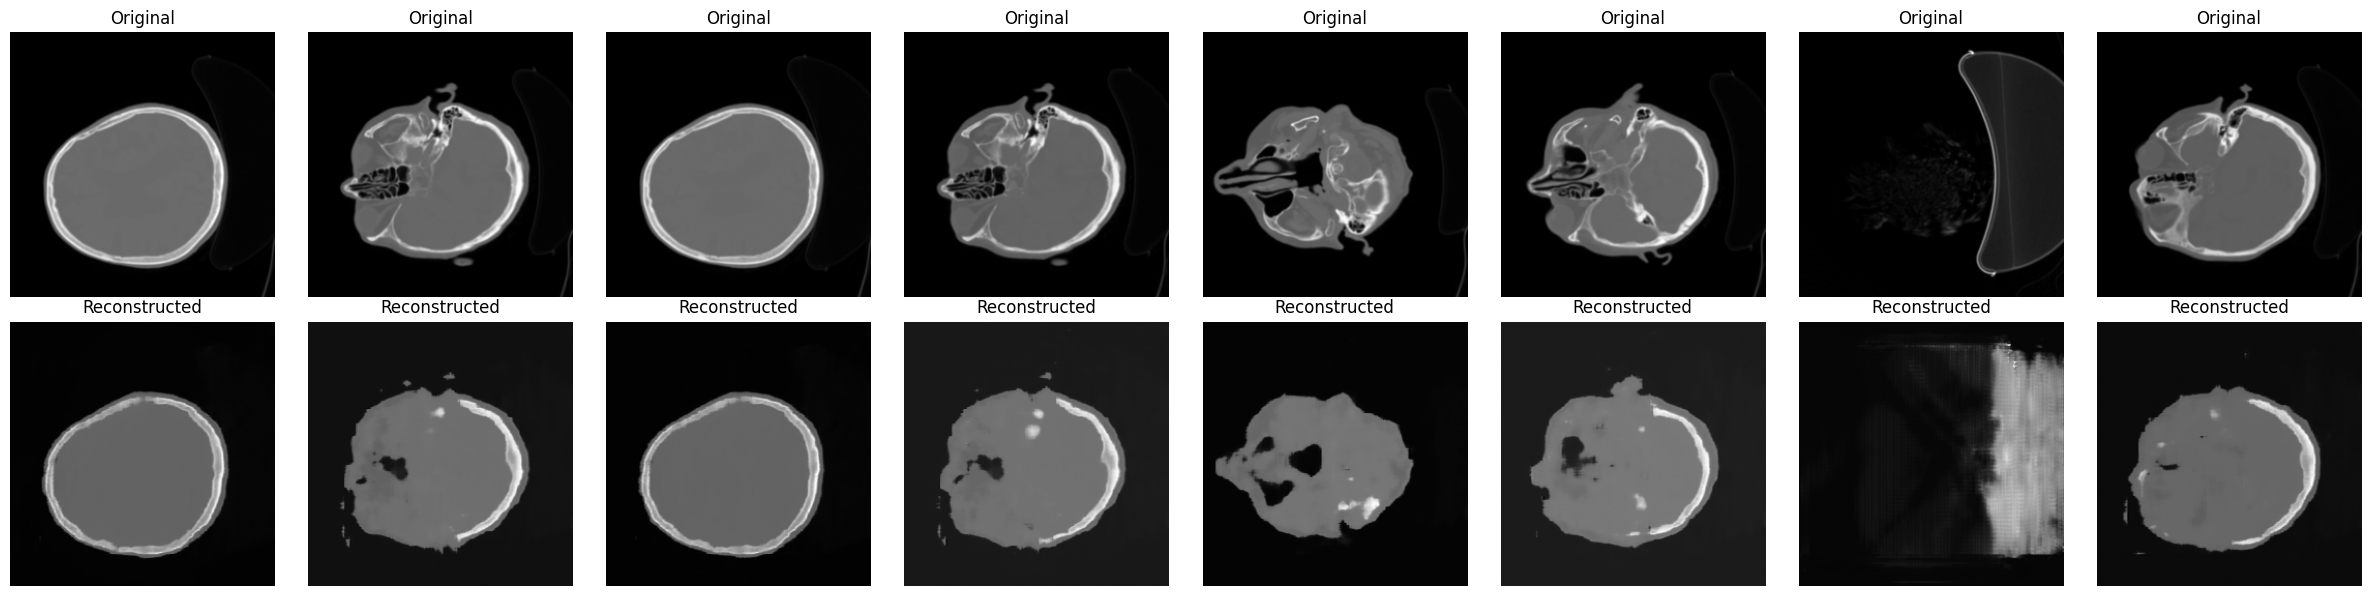

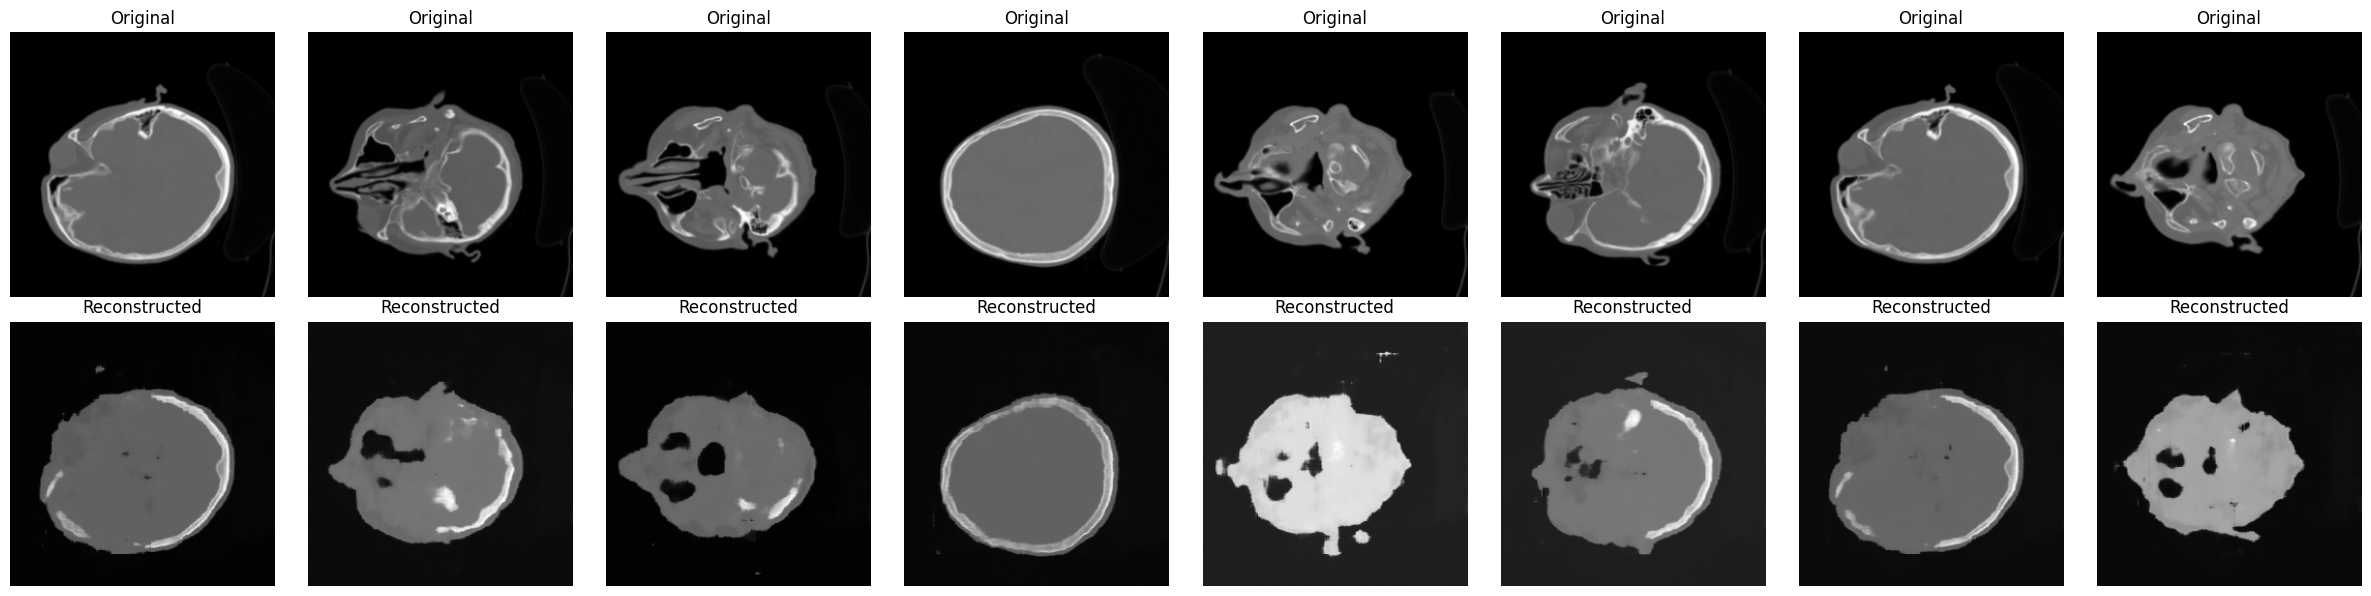

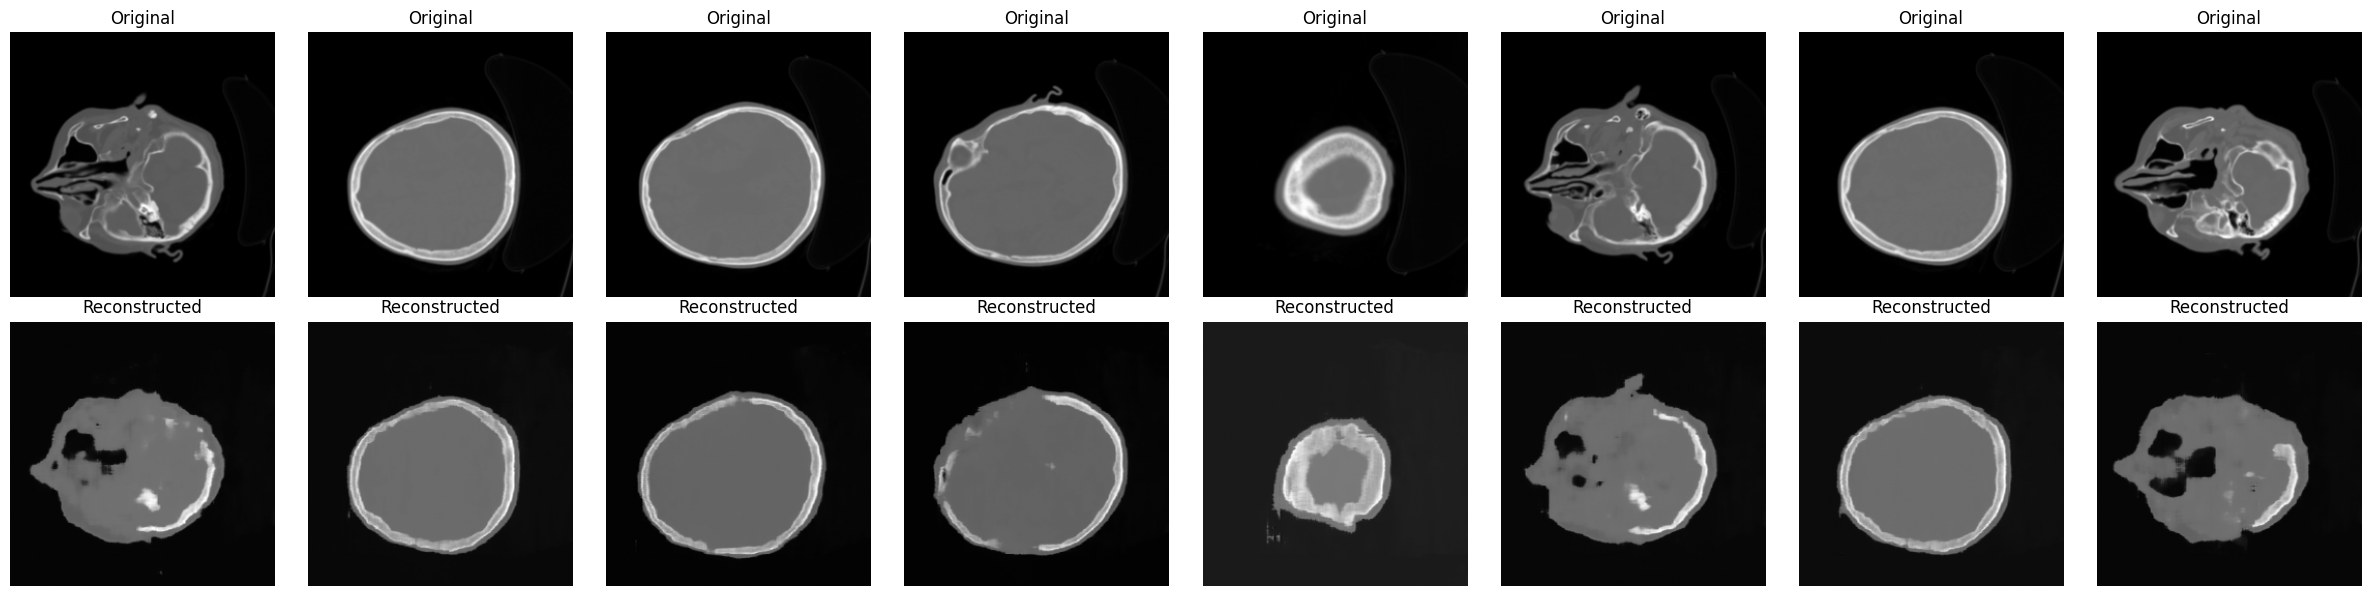

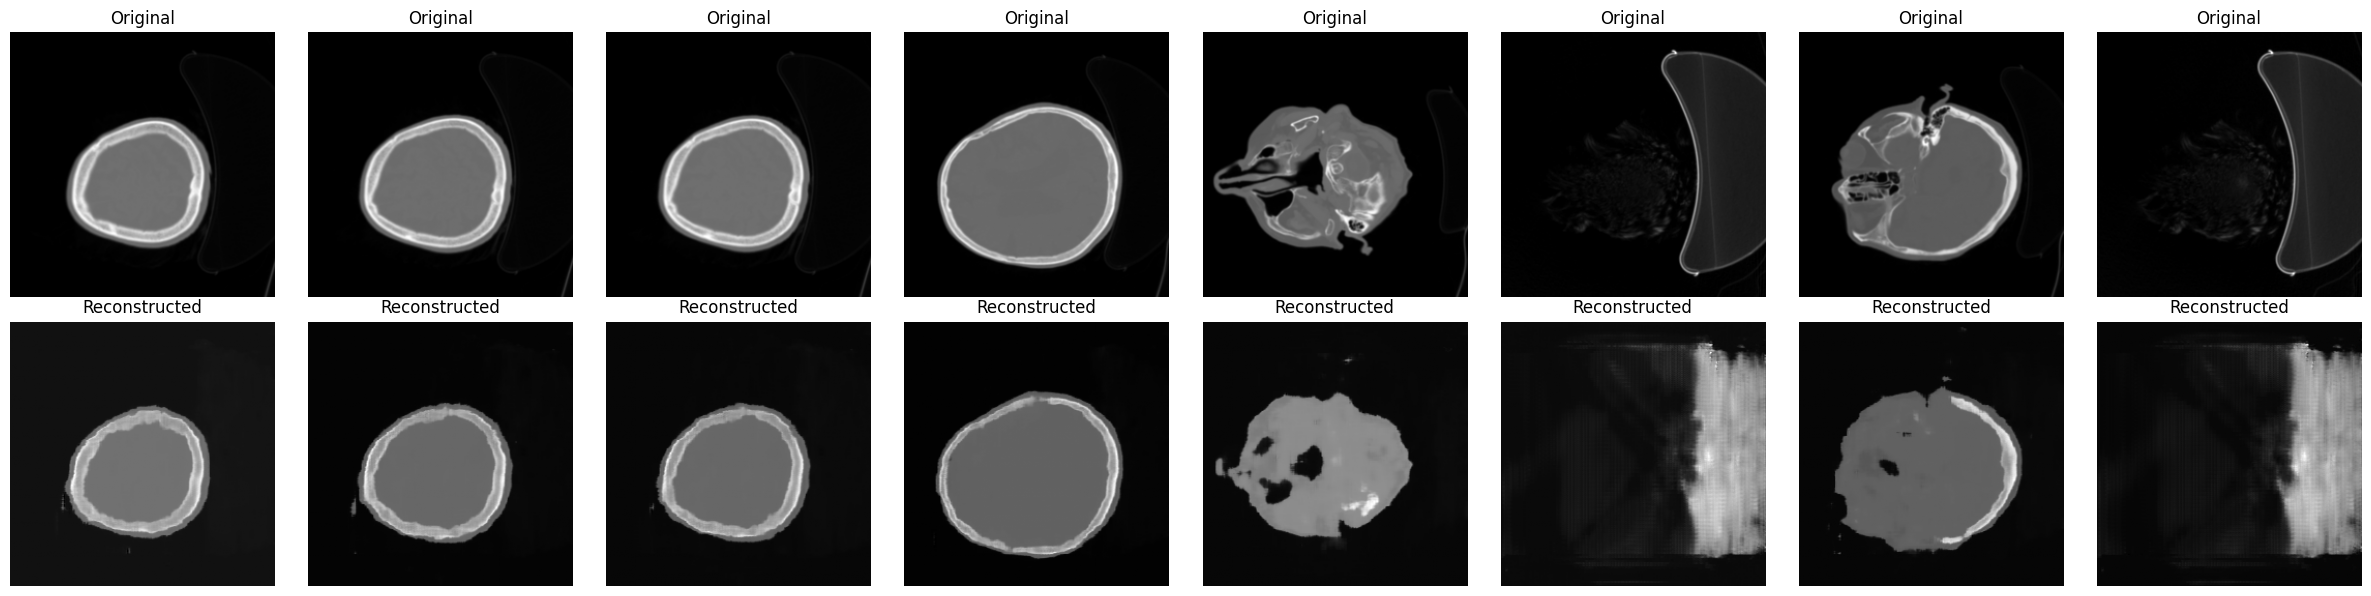

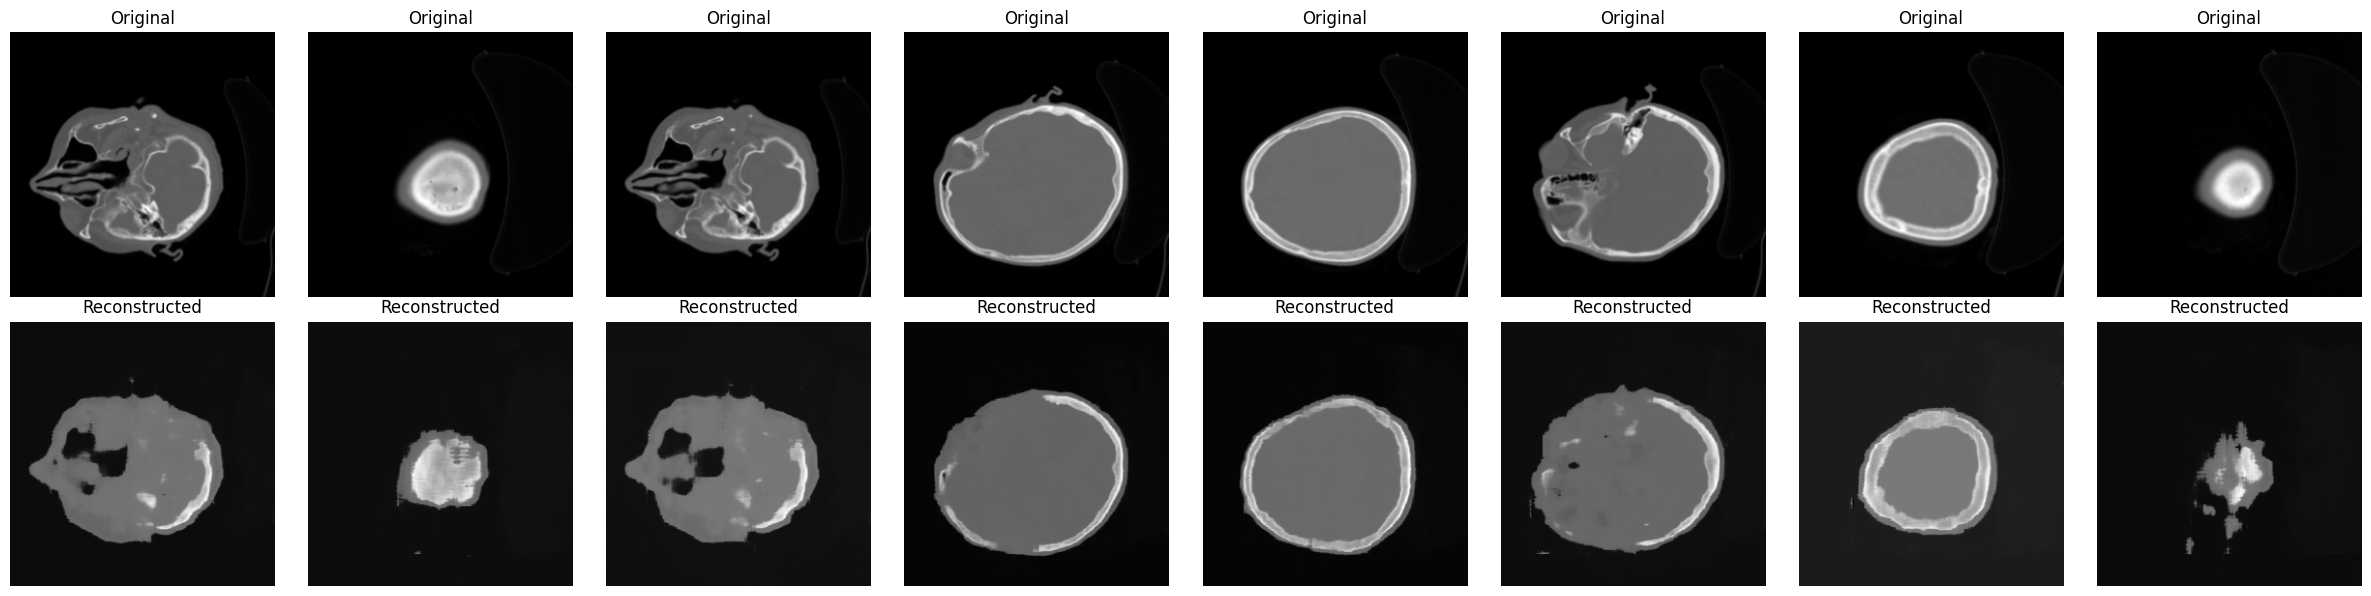

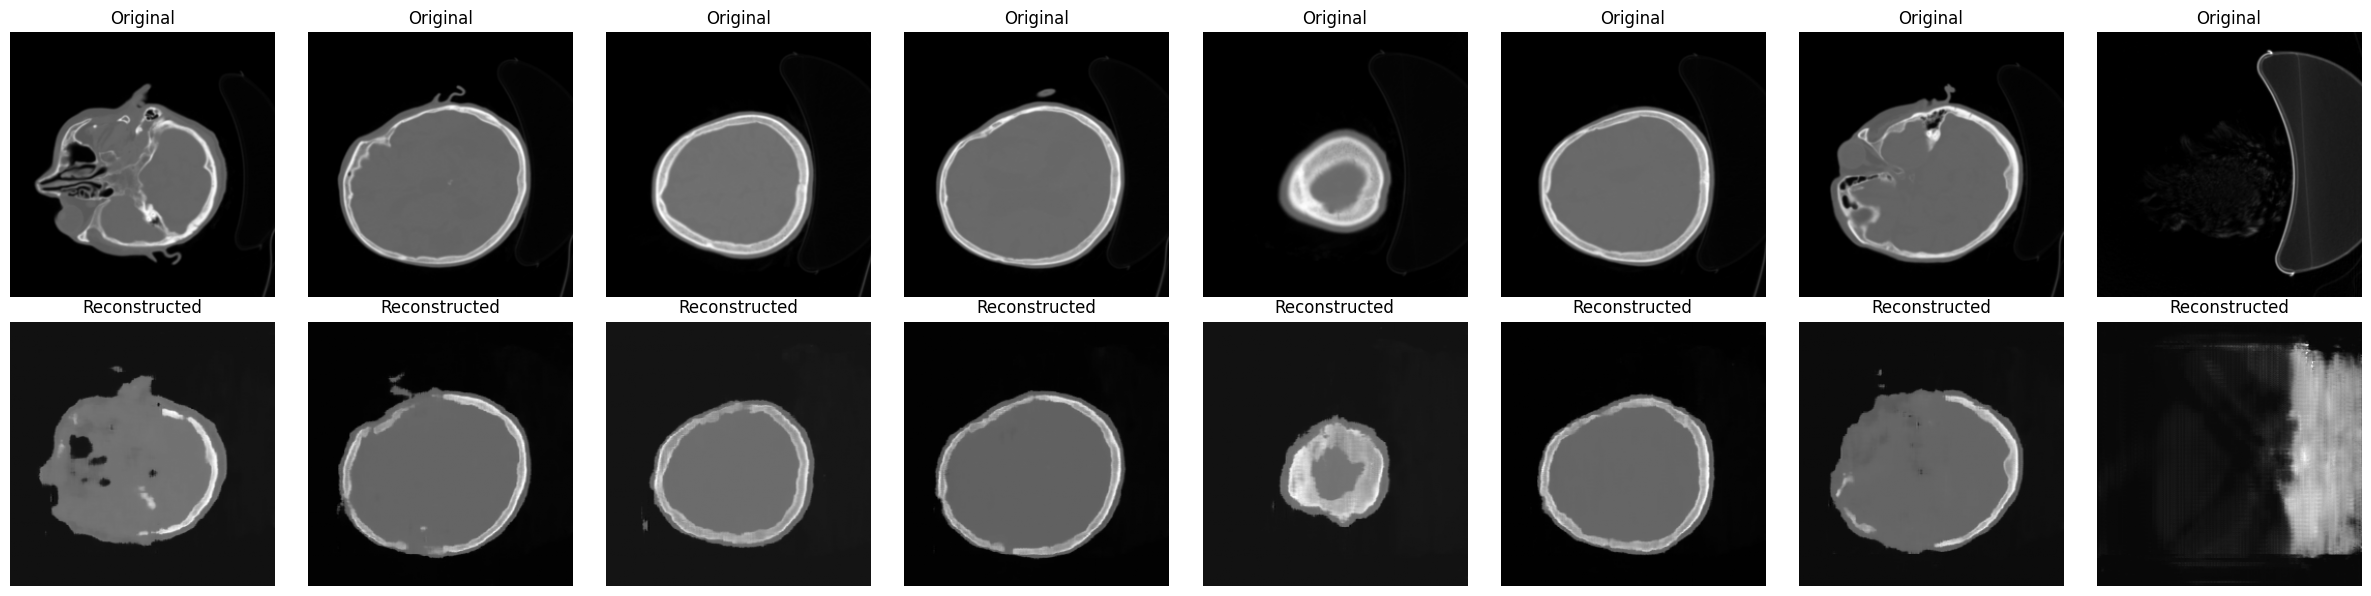

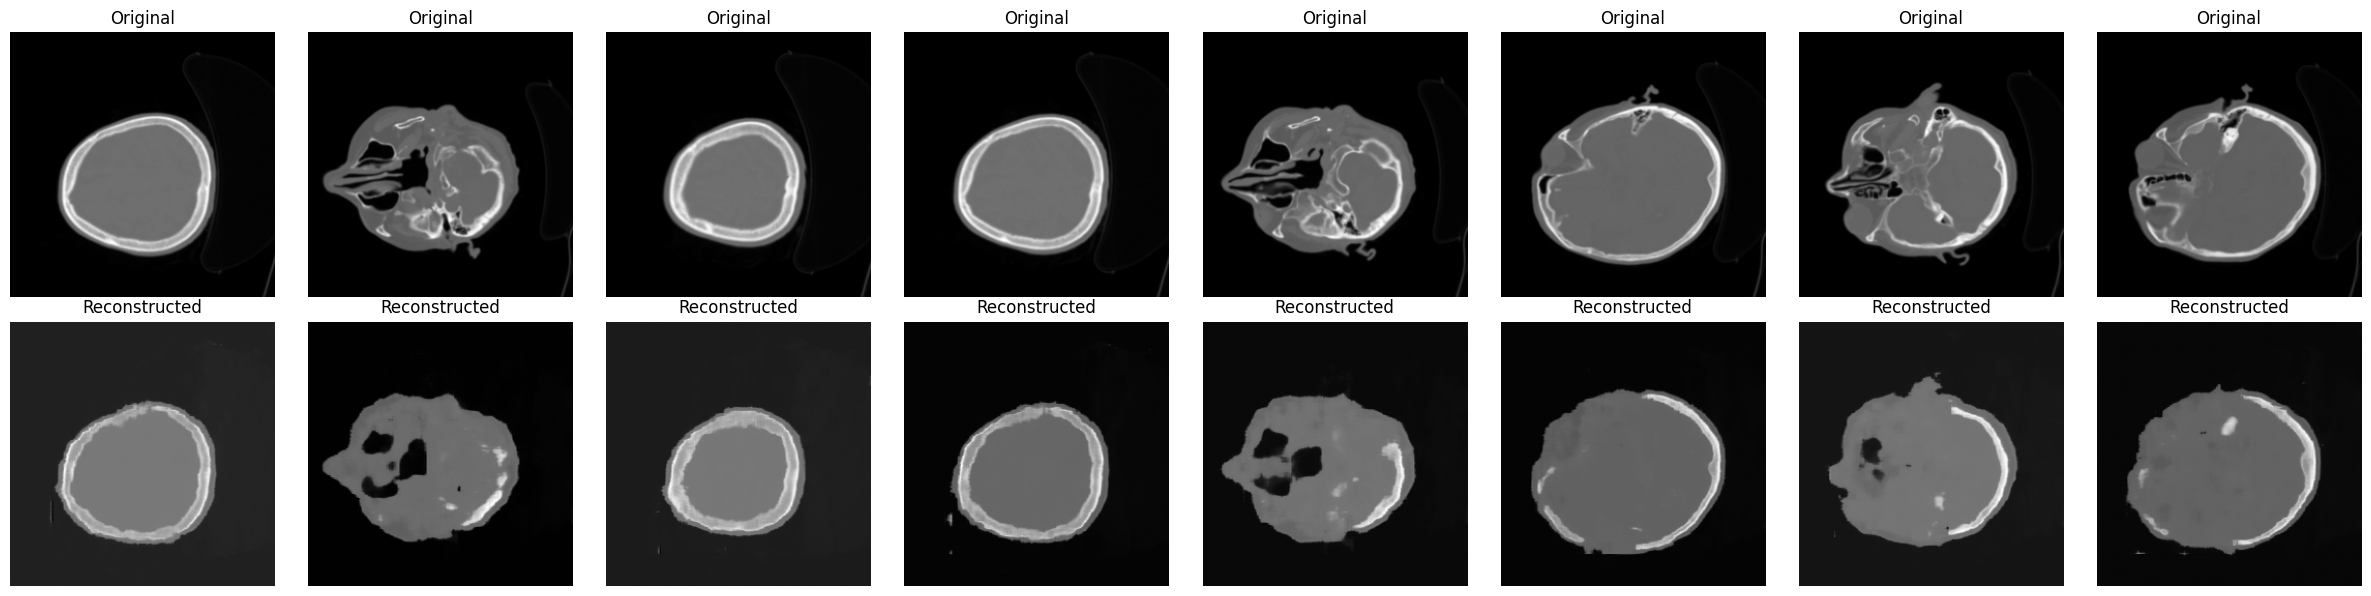

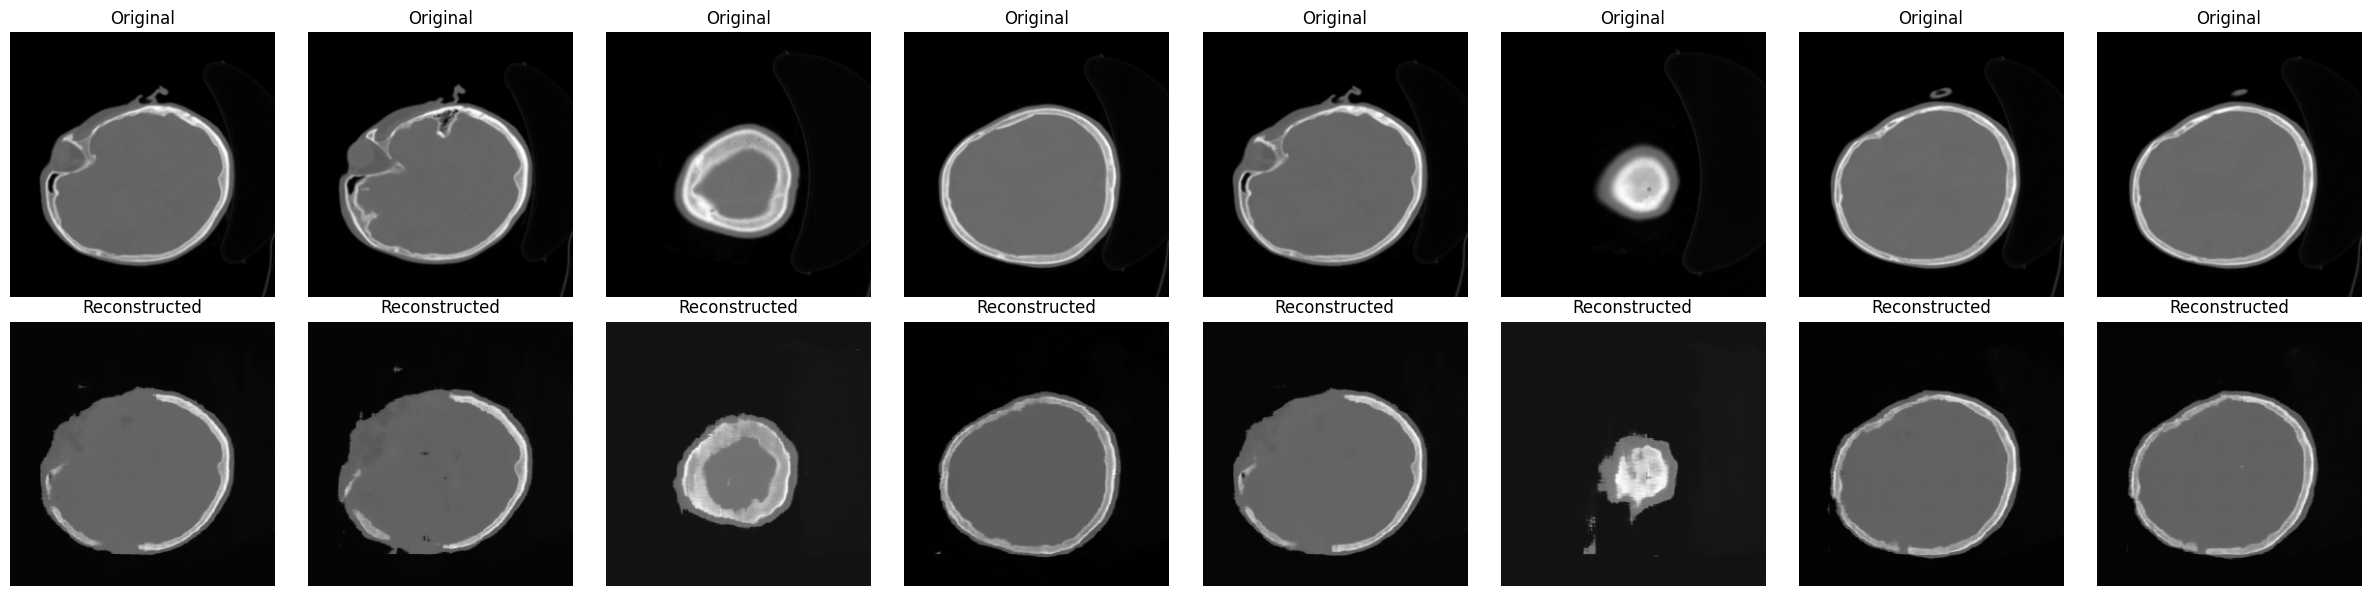

In [10]:
import matplotlib.pyplot as plt

def show_reconstructed_images(model, dataloader, device, num_images=5):
    model.eval()
    shown = 0
    with torch.no_grad():
        for sino, img in dataloader:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            output = model(sino)

            batch_size = img.size(0)
            n = min(batch_size, num_images - shown)

            # Create a figure with 2 rows: original and reconstructed
            fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(3 * n, 6))

            for i in range(n):
                # Original image
                axes[0, i].imshow(img[i].cpu().numpy().squeeze(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")

                # Reconstructed image
                axes[1, i].imshow(output[i].cpu().numpy().squeeze(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")

            plt.tight_layout()
            plt.show()

            shown += n
            if shown >= num_images:
                break

show_reconstructed_images(generator, test_loader, device, num_images=64)